# NGC4254 Spiral Arm Geometry and Profile Fitting
This notebook takes the first two python cells of `KTZ_validation.ipynb` and extends the analysis to the real spiral galaxy **NGC4254** using the HII SFR map (`LOGSFR_SURFACE_DENSITY_HII` from `NGC4254_gas_bin_maps_further.fits`).

We load the coordinates of the optical center, inclination, and position angle of NGC4254 from `Brown2021Table1.txt` to deproject the SFR map, fit the axisymmetric radial background, perform a local-ridge search to select the spiral geometry, fit the KTZ harmonic profile, and plot the spiral skeleton and arm profile.

In [1]:
# %% Block 1: Import packages and set global parameters
import numpy as np
from numpy.random import default_rng
from scipy.special import exp1
from scipy.integrate import quad
from scipy.interpolate import RegularGridInterpolator, interp1d
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# M101-like fiducial setup, calibrated to the observed star-forming main disc.
# M101 has an extended faint outer disc, but this notebook uses the brighter main disc
# where HII-region and spiral-arm measurements are better sampled.
R_in, R_out = 1.0, 14.4

# Diffusion parameters.  These control the KTZ smoothing scale,
# ell_K = sqrt(x0^2 + 2 kappa t), rather than direct observables.
kappa = 0.30         # kpc^2/Gyr
x0 = 0.10            # initial smoothing length (kpc)
t_star = 0.50        # maximum source age (Gyr)

# Spiral structure.  M101 is asymmetric and multi-armed; pitch angles vary by segment.
# A single logarithmic spiral is only a fiducial approximation.  Try 15, 20, and 25 deg.
m_arms = 2
pitch_angle = 20.0   # degree
pitch_rad = np.deg2rad(pitch_angle)
Theta0 = 0.0

# Spiral arm modulation h(Theta) = sum_n g_n cos(n Theta + alpha_n).
# Keep all harmonic parameters here; the numerical source rate and KTZ theory
# blocks read these arrays directly.
eta = 0.40
harmonic_n = np.array([1, 2, 3], dtype=int)
harmonic_g = np.array([1.00, 0.40, 0.20], dtype=float)
harmonic_alpha = np.array([0.00, 0.00, 0.00], dtype=float)

def h_func(Theta):
    Theta = np.asarray(Theta)
    h_val = np.zeros_like(Theta, dtype=float)
    for n, g, alpha in zip(harmonic_n, harmonic_g, harmonic_alpha):
        h_val = h_val + g*np.cos(n*Theta + alpha)
    return h_val

Theta_check = np.linspace(0, 2*np.pi, 4096, endpoint=False)
rate_floor = 1.0 + eta*np.min(h_func(Theta_check))
if rate_floor <= 0:
    raise ValueError("Spiral harmonic settings make lambda_rate negative; lower eta or harmonic_g.")

# Background rate $\lambda_0(\varpi) = \lambda_{00} \exp(-\varpi/h_R)$.
# h_R approx 4.8 kpc follows the main-disc boundary at roughly three scale lengths.
# lambda0_0 is an effective event rate; rescale it if one synthetic event represents
# a different stellar mass or yield unit.
lambda0_0 = 5.0e2   # kpc^-2 Gyr^-1
h_R = 4.8

# Source clustering.  The clustered component is a Thomas process:
# parent complexes are sampled from the same mean spiral-modulated rate,
# and child enrichment events are scattered around each parent.
enable_source_clustering = True
cluster_fraction = 0.50              # fraction of events drawn from clustered complexes
cluster_radius = 0.35                # kpc, one-sigma child offset around each parent
mean_children_per_cluster = 5.0      # mean child events per parent complex
cluster_theory_nodes = 24            # quadrature nodes for the C_NP age integral

# Output (fixed)
Y_val = 1.0

# Computational grid.
dx = 0.20
grid_radius = R_out + 1.0

# Number of independent numerical realizations used to estimate error bands.
# Increase this for publication-quality uncertainty estimates.
n_realizations = 10

rng = default_rng(42)
print("The settings have been configured.")

The settings have been configured.


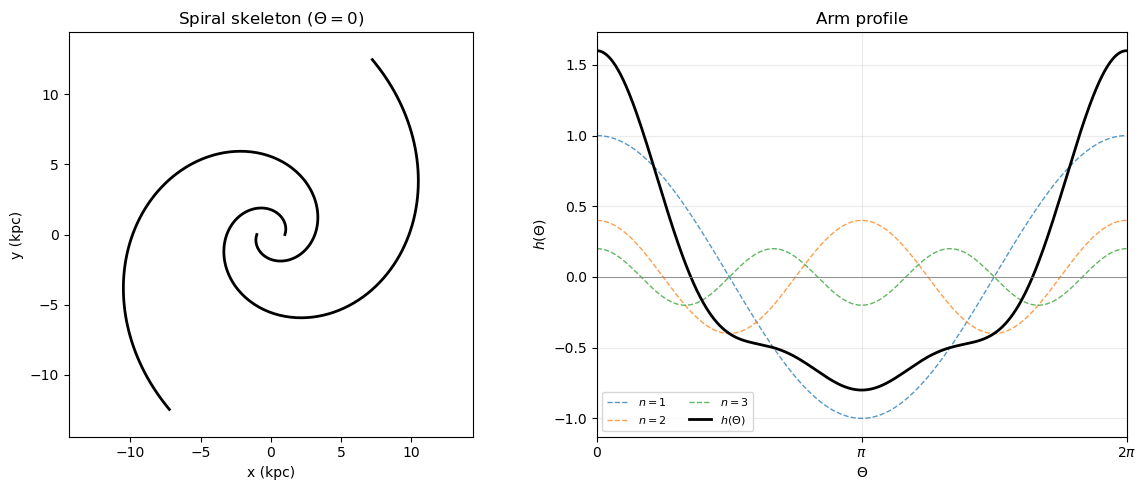

In [2]:
# %% Section 2: Definition of auxiliary functions (spiral phase, source rate, wavenumber)
def spiral_phase(varpi, phi):
    r"""The phase of a logarithmic spiral $\Theta$."""
    Phi = (m_arms / np.tan(pitch_rad)) * np.log(varpi / R_in)
    return Phi - m_arms * phi + Theta0

def lambda_rate(varpi, phi):
    r"""Non-uniform event rate $\lambda(\varpi,\phi)$."""
    lam0 = lambda0_0 * np.exp(-varpi / h_R)
    #lam0 = lambda0_0
    Theta = spiral_phase(varpi, phi)
    return lam0 * (1.0 + eta * h_func(Theta))

def k_perp(varpi):
    r"""Local arm-normal wavenumber $k_\perp$."""
    dPhi = (m_arms / np.tan(pitch_rad)) / varpi
    return np.sqrt(dPhi**2 + (m_arms / varpi)**2)

# Visualising the spiral pattern and its arm-profile harmonics.
phi_plot = np.linspace(0, 2*np.pi, 500)
varpi_plot = np.linspace(R_in, R_out, 200)
profile_theta = np.linspace(0, 2*np.pi, 600)
profile_total = h_func(profile_theta)

fig, (ax_spiral, ax_profile) = plt.subplots(1, 2, figsize=(12, 5))
for k in range(m_arms):
    # Solve Phi(varpi) - m*phi + Theta0 = 0 -> phi = (Phi(varpi) + Theta0 + 2*pi*k)/m.
    phi_sp = ((m_arms / np.tan(pitch_rad)) * np.log(varpi_plot / R_in) + Theta0 + 2*np.pi*k) / m_arms
    ax_spiral.plot(varpi_plot * np.cos(phi_sp), varpi_plot * np.sin(phi_sp), 'k-', lw=2)
ax_spiral.set_xlim(-R_out, R_out)
ax_spiral.set_ylim(-R_out, R_out)
ax_spiral.set_aspect('equal')
ax_spiral.set_title(r'Spiral skeleton ($\Theta = 0$)')
ax_spiral.set_xlabel('x (kpc)')
ax_spiral.set_ylabel('y (kpc)')

for n, g, alpha in zip(harmonic_n, harmonic_g, harmonic_alpha):
    component = g*np.cos(n*profile_theta + alpha)
    ax_profile.plot(profile_theta, component, '--', lw=1, alpha=0.75, label=fr'$n={n}$')
ax_profile.plot(profile_theta, profile_total, 'k-', lw=2, label=r'$h(\Theta)$')
ax_profile.axhline(0, color='grey', lw=0.6)
ax_profile.set_xlim(0, 2*np.pi)
ax_profile.set_xticks([0, np.pi, 2*np.pi])
ax_profile.set_xticklabels([r'$0$', r'$\pi$', r'$2\pi$'])
ax_profile.set_xlabel(r'$\Theta$')
ax_profile.set_ylabel(r'$h(\Theta)$')
ax_profile.set_title(r'Arm profile')
ax_profile.grid(alpha=0.25)
ax_profile.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


## Real Data Analysis for NGC4254
Below we load the FITS data and the Brown (2021) catalog to run the deprojection, local-ridge search, profile fitting, and plotting for NGC4254.

In [3]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import FK5, SkyCoord
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.optimize import least_squares, minimize_scalar

ROOT = Path.cwd().resolve()
FITS_PATH = ROOT / "v3tk_v7.6.8/NGC4254/NGC4254_gas_bin_maps_further.fits"
BROWN_TABLE = ROOT / "Brown2021Table1.txt"
UPSTREAM_SFR_LOG = ROOT / "sfr_logs/NGC4254.log"
SFR_HDU = "LOGSFR_SURFACE_DENSITY_HII"
BIN_HDU = "BIN_ID"

DISTANCE_MPC = 16.5
Q0 = 0.2
SURFACE_DENSITY_ALREADY_CORRECTED = True
APPLY_BA_CORRECTION_IN_NOTEBOOK = False
R_REF_KPC = 1.0
M_CANDIDATES = np.arange(1, 7, dtype=int)
RIDGE_PITCH_GRID_DEG = np.concatenate((np.arange(-45.0, -4.9, 1.0),
                                       np.arange(5.0, 45.1, 1.0)))
RIDGE_CORE_WIDTH_KPC = 0.25
RIDGE_WIDTH_SENSITIVITY_KPC = np.array([0.18, 0.22, 0.25, 0.30, 0.35])
RIDGE_BROAD_RATIO = 3.0
RIDGE_N_PHASE = 360
RIDGE_N_SECTORS = 12
RIDGE_MIN_HELD_OUT_SECTORS = 10
RIDGE_SHORTLIST_PER_FAMILY = 5
RIDGE_N_NULL = 8
LOGPOLAR_N_U = 120
LOGPOLAR_N_PHI = 360
LOGPOLAR_N_RADIAL_BANDS = 24
LOGPOLAR_SMOOTH_SIGMA = (0.8, 1.2)
LOGPOLAR_AZIMUTH_BROAD_SIGMA_BINS = 30.0
HARMONIC_N = np.array([1, 2, 3], dtype=int)
USE_ALL_VALID_HII_BINS = True
N_BOOTSTRAP = 24
N_BOOTSTRAP_SECTORS = 12
RNG_SEED = 4254
rng = np.random.default_rng(RNG_SEED)


def load_brown_geometry(path, galaxy="NGC 4254"):
    if not path.exists():
        raise FileNotFoundError(path)
    rows = [line.rstrip("\n") for line in path.read_text(encoding="utf-8").splitlines()
            if line.startswith(galaxy)]
    if len(rows) != 1:
        raise RuntimeError(f"Expected one {galaxy} row in {path}; found {len(rows)}")
    fields = rows[0].split("\t")
    if len(fields) < 6:
        raise ValueError(f"Malformed Brown table row: {rows[0]}")
    ra_match = re.fullmatch(r"(\d+)\^h(\d+)\^m(\d+)\.s(\d+)", fields[1])
    dec_match = re.fullmatch(r"([+-]?\d+)deg(\d+)'(\d+)\.\"(\d+)", fields[2])
    if ra_match is None or dec_match is None:
        raise ValueError(f"Unrecognized Brown coordinates: {fields[1:3]}")
    hh, mm, ss, sf = ra_match.groups()
    dd, dm, ds, df = dec_match.groups()
    sign = "-" if dd.startswith("-") else "+"
    dd_abs = dd.lstrip("+-")
    coordinate = SkyCoord(
        f"{hh}h{mm}m{ss}.{sf}s",
        f"{sign}{dd_abs}d{dm}m{ds}.{df}s",
        frame=FK5(equinox="J2000"),
    )
    return {
        "center": coordinate,
        "inclination_deg": float(fields[4]),
        "position_angle_deg": float(fields[5]),
        "source_row": rows[0],
    }


def finite_thickness_axis_ratio(inclination_deg, q0=Q0):
    cosine = np.cos(np.deg2rad(float(inclination_deg)))
    return float(np.sqrt((1.0 - q0**2) * cosine**2 + q0**2))


BROWN_GEOMETRY = load_brown_geometry(BROWN_TABLE)
CENTER = BROWN_GEOMETRY["center"]
INCLINATION_DEG = BROWN_GEOMETRY["inclination_deg"]
POSITION_ANGLE_DEG = BROWN_GEOMETRY["position_angle_deg"]
B_OVER_A = finite_thickness_axis_ratio(INCLINATION_DEG)
EXPECTED_CENTER = SkyCoord("12h18m49.68s", "+14d25m05.52s",
                           frame=FK5(equinox="J2000"))
assert CENTER.separation(EXPECTED_CENTER).to_value(u.arcsec) < 1e-6
assert np.isclose(INCLINATION_DEG, 39.0)
assert np.isclose(POSITION_ANGLE_DEG % 360.0, 243.0)
assert np.isclose(B_OVER_A, 0.787, atol=5e-4)
assert SURFACE_DENSITY_ALREADY_CORRECTED
assert not APPLY_BA_CORRECTION_IN_NOTEBOOK
upstream_text = UPSTREAM_SFR_LOG.read_text(encoding="utf-8")
upstream_matches = re.findall(
    r"Inclination correction ENABLED: applying b/a = ([0-9.]+)",
    upstream_text,
)
if not upstream_matches:
    raise RuntimeError(f"No enabled b/a correction record in {UPSTREAM_SFR_LOG}")
assert np.isclose(float(upstream_matches[-1]), B_OVER_A, atol=5e-4)
print(f"Brown catalog row: {BROWN_GEOMETRY['source_row']}")
print(f"Adopted FK5 J2000 centre: {CENTER.to_string('hmsdms')}")
print(f"Inclination={INCLINATION_DEG:.1f} deg; directed PA={POSITION_ANGLE_DEG:.1f} deg east of north")
print("BROWN_GEOMETRY_PASS")
print(f"Equation-3 finite-thickness factor b/a={B_OVER_A:.4f}; already applied upstream")
print("BA_FACTOR_PASS")
print(f"Confirmed upstream correction record: b/a={float(upstream_matches[-1]):.3f}")
print("UPSTREAM_BA_PASS")

plt.style.use("default")
plt.rcParams.update({"figure.dpi": 115, "font.size": 10})
warnings.filterwarnings("default")
print(f"Project root: {ROOT}")
print(f"Input product: {FITS_PATH}")


Brown catalog row: NGC 4254 ^a ^, ^b	12^h18^m49.s68	14deg25'05."52	2453	39	243	
Adopted FK5 J2000 centre: 12h18m49.68s +14d25m05.52s
Inclination=39.0 deg; directed PA=243.0 deg east of north
BROWN_GEOMETRY_PASS
Equation-3 finite-thickness factor b/a=0.7873; already applied upstream
BA_FACTOR_PASS
Confirmed upstream correction record: b/a=0.787
UPSTREAM_BA_PASS
Project root: /Users/Igniz/Desktop/ICRAR/further
Input product: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/NGC4254/NGC4254_gas_bin_maps_further.fits


In [4]:
def load_maps(path, sfr_hdu=SFR_HDU, bin_hdu=BIN_HDU):
    'Read the log-SFR and bin-ID maps and return an independent celestial WCS.'
    if not path.exists():
        raise FileNotFoundError(path)
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name for hdu in hdul}
        missing = [name for name in (sfr_hdu, bin_hdu) if name not in names]
        if missing:
            raise KeyError(f"Missing required HDUs: {missing}")
        log_sfr = np.asarray(hdul[sfr_hdu].data, dtype=float).copy()
        bin_id = np.asarray(hdul[bin_hdu].data, dtype=float).copy()
        header = hdul[sfr_hdu].header.copy()
    if log_sfr.shape != bin_id.shape:
        raise ValueError(f"Map shape mismatch: {log_sfr.shape} versus {bin_id.shape}")
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("Target HDU does not contain a celestial WCS")
    return log_sfr, bin_id, header, wcs


log_sfr_map, bin_id_map, sfr_header, celestial_wcs = load_maps(FITS_PATH)
wcs_reference = SkyCoord(
    celestial_wcs.wcs.crval[0] * u.deg,
    celestial_wcs.wcs.crval[1] * u.deg,
    frame=FK5(equinox="J2000"),
)
wcs_center_separation_arcsec = float(
    wcs_reference.separation(CENTER).to_value(u.arcsec))
assert wcs_center_separation_arcsec > 1.0
print(f"FITS CRVAL is a WCS projection reference, not the Brown optical centre; "
      f"separation={wcs_center_separation_arcsec:.3f} arcsec")
print("WCS_REFERENCE_NOT_CENTER_PASS")
finite_sfr = np.isfinite(log_sfr_map)
print(f"Map shape: {log_sfr_map.shape}")
print(f"Finite HII SFR pixels: {finite_sfr.sum():,}")
print(f"Finite log SFR range: {np.nanmin(log_sfr_map):.3f} to {np.nanmax(log_sfr_map):.3f}")


def build_bin_catalog(log_sfr, bin_id, wcs):
    'Return one centroid and one SFR measurement per valid adaptive gas bin.'
    valid = np.isfinite(log_sfr) & np.isfinite(bin_id) & (bin_id >= 0)
    yy, xx = np.nonzero(valid)
    ids = bin_id[valid].astype(np.int64)
    values = log_sfr[valid]
    unique_ids, inverse = np.unique(ids, return_inverse=True)
    area_pix = np.bincount(inverse).astype(float)
    x_centroid = np.bincount(inverse, weights=xx) / area_pix
    y_centroid = np.bincount(inverse, weights=yy) / area_pix
    mean_log_sfr = np.bincount(inverse, weights=values) / area_pix
    ra_deg, dec_deg = wcs.pixel_to_world_values(x_centroid, y_centroid)
    table = pd.DataFrame({
        "bin_id": unique_ids,
        "x_pix": x_centroid,
        "y_pix": y_centroid,
        "ra_deg": ra_deg,
        "dec_deg": dec_deg,
        "area_pix": area_pix,
        "log_sfr": mean_log_sfr,
        "sfr_linear": np.power(10.0, mean_log_sfr),
    })
    if len(table) < 100:
        raise ValueError(f"Only {len(table)} valid HII bins; spiral fitting is not supported")
    return table, valid


bin_table, valid_hii_pixels = build_bin_catalog(log_sfr_map, bin_id_map, celestial_wcs)
assert bin_table["bin_id"].is_unique
assert np.all(bin_table["area_pix"] > 0)
assert np.all(np.isfinite(bin_table["sfr_linear"]))
print(f"Independent valid HII gas bins: {len(bin_table):,}")
print(f"Median represented area: {bin_table['area_pix'].median():.0f} image pixels")
display(bin_table.head())


FITS CRVAL is a WCS projection reference, not the Brown optical centre; separation=26.555 arcsec
WCS_REFERENCE_NOT_CENTER_PASS
Map shape: (1190, 1012)
Finite HII SFR pixels: 681,856
Finite log SFR range: -3.533 to 0.375
Independent valid HII gas bins: 32,552
Median represented area: 8 image pixels


,bin_id,x_pix,y_pix,ra_deg,dec_deg,area_pix,log_sfr,sfr_linear
0,58,586.0,471.0,184.706783,14.416218,1.0,-0.668133,0.214717
1,59,589.0,471.0,184.706611,14.416218,1.0,-0.744630,0.180040
2,63,584.0,472.0,184.706898,14.416273,1.0,-0.600574,0.250857
3,65,585.0,471.0,184.706841,14.416218,1.0,-0.535804,0.291203
4,66,583.0,473.0,184.706956,14.416329,1.0,-0.653558,0.222045


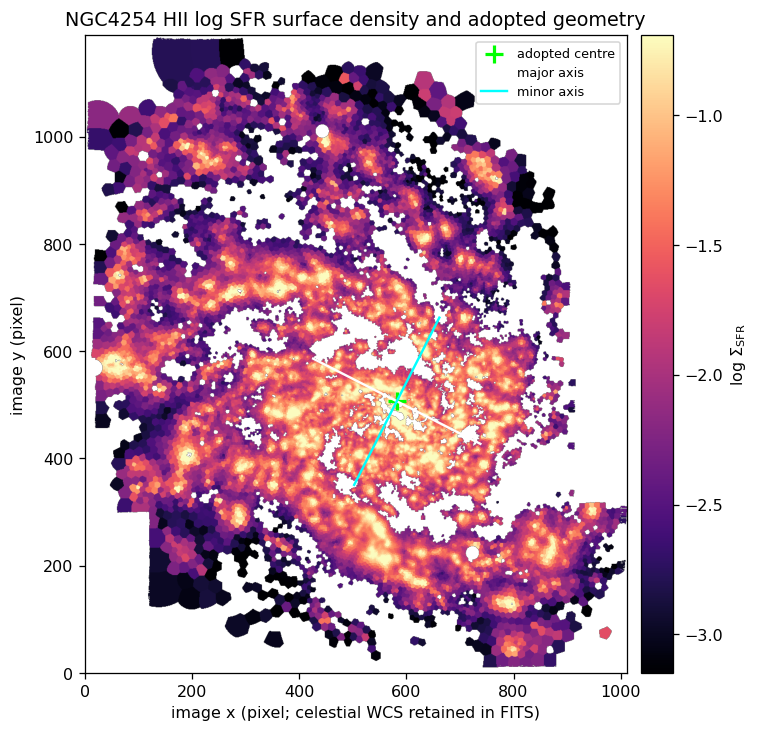

In [5]:
fig, ax = plt.subplots(figsize=(8.2, 7.2))
vmin, vmax = np.nanpercentile(log_sfr_map[finite_sfr], [2, 98])
image = ax.imshow(log_sfr_map, origin="lower", cmap="magma", vmin=vmin, vmax=vmax)
cx, cy = celestial_wcs.world_to_pixel(CENTER)
ax.scatter(cx, cy, marker="+", s=140, linewidth=2.0, color="lime", label="adopted centre")
length_pix = 260.0
pa = np.deg2rad(POSITION_ANGLE_DEG)
# Image x increases approximately east-to-west because CDELT1 is negative; draw axes via sky offsets.
for angle_deg, color, label in [(POSITION_ANGLE_DEG, "white", "major axis"),
                                (POSITION_ANGLE_DEG + 90.0, "cyan", "minor axis")]:
    angle = np.deg2rad(angle_deg)
    dra = np.sin(angle) * 35.0 * u.arcsec
    ddec = np.cos(angle) * 35.0 * u.arcsec
    end1 = CENTER.directional_offset_by(np.arctan2(dra.value, ddec.value) * u.rad,
                                        np.hypot(dra.value, ddec.value) * u.arcsec)
    end2 = CENTER.directional_offset_by((np.arctan2(dra.value, ddec.value) + np.pi) * u.rad,
                                        np.hypot(dra.value, ddec.value) * u.arcsec)
    x1, y1 = celestial_wcs.world_to_pixel(end1)
    x2, y2 = celestial_wcs.world_to_pixel(end2)
    ax.plot([x1, x2], [y1, y2], color=color, lw=1.5, label=label)
ax.set_xlim(0, log_sfr_map.shape[1]-1)
ax.set_ylim(0, log_sfr_map.shape[0]-1)
ax.set_aspect("equal")
ax.set_xlabel("image x (pixel; celestial WCS retained in FITS)")
ax.set_ylabel("image y (pixel)")
ax.set_title("NGC4254 HII log SFR surface density and adopted geometry")
ax.legend(loc="upper right", fontsize=8)
fig.colorbar(image, ax=ax, pad=0.02, label=r"log $\Sigma_{\rm SFR}$")
plt.show()


1 arcsec = 0.0800 kpc at 16.5 Mpc
Fitting radius: 0.0085 to 13.1635 kpc; no artificial centre or outer cut
Retained bins: 32,552 / 32,552
Represented valid HII pixels: 681,856 / 681,856
FIT_DOMAIN_ALL_VALID_HII_PASS


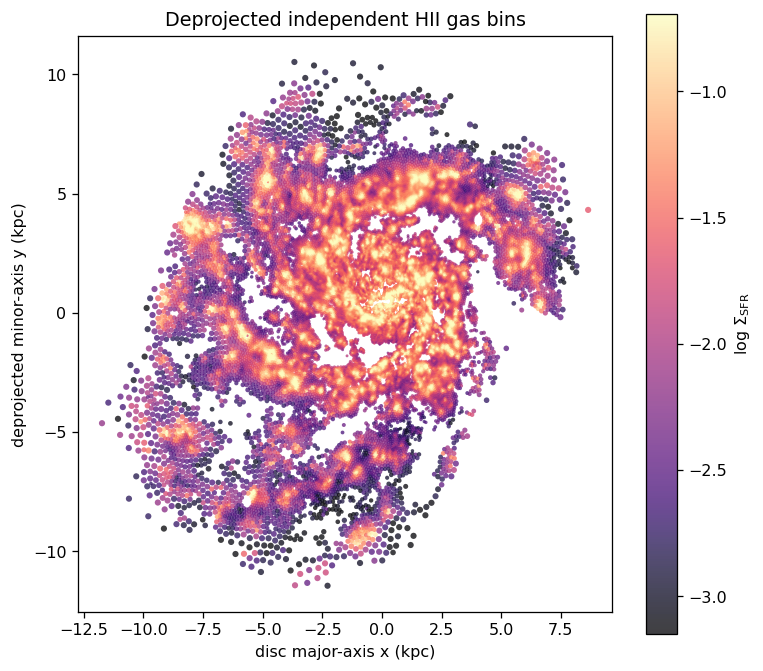

Ridge morphology pixels: 681,856 / 681,856
Ridge pixel radius: 0.0066 to 13.9896 kpc; phase pivot=7.121 kpc
RIDGE_PIXEL_DOMAIN_PASS


In [6]:
ARCSEC_TO_KPC = DISTANCE_MPC * 1.0e3 / 206265.0


def deproject_sky(ra_deg, dec_deg):
    'Convert FK5 J2000 sky coordinates to deprojected major/minor coordinates in kpc.'
    coords = SkyCoord(np.asarray(ra_deg) * u.deg,
                      np.asarray(dec_deg) * u.deg,
                      frame=FK5(equinox="J2000"))
    dlon, dlat = CENTER.spherical_offsets_to(coords)
    east_kpc = dlon.to_value(u.arcsec) * ARCSEC_TO_KPC
    north_kpc = dlat.to_value(u.arcsec) * ARCSEC_TO_KPC
    pa_rad = np.deg2rad(POSITION_ANGLE_DEG)
    inc_rad = np.deg2rad(INCLINATION_DEG)
    major = east_kpc * np.sin(pa_rad) + north_kpc * np.cos(pa_rad)
    minor_projected = -east_kpc * np.cos(pa_rad) + north_kpc * np.sin(pa_rad)
    minor = minor_projected / np.cos(inc_rad)
    radius = np.hypot(major, minor)
    azimuth = np.arctan2(minor, major)
    return major, minor, radius, azimuth


# A direct unit check: the adopted sky centre must map to the disc origin.
origin = deproject_sky([CENTER.ra.deg], [CENTER.dec.deg])
assert np.allclose([origin[0][0], origin[1][0]], 0.0, atol=1.0e-10)

values = deproject_sky(bin_table["ra_deg"], bin_table["dec_deg"])
bin_table[["x_disc_kpc", "y_disc_kpc", "radius_kpc", "azimuth_rad"]] = np.column_stack(values)
# Keep every finite HII bin. The logarithmic spiral is undefined only at exactly R=0;
# no valid bin centroid lies exactly at the adopted centre in this product.
fit_mask = np.isfinite(bin_table["radius_kpc"]) & (bin_table["radius_kpc"] > 0.0)
fit_table = bin_table.loc[fit_mask].reset_index(drop=True)
R_IN_KPC = float(fit_table["radius_kpc"].min())
R_OUT_KPC = float(fit_table["radius_kpc"].max())
assert USE_ALL_VALID_HII_BINS
assert len(fit_table) == len(bin_table)
assert int(fit_table["area_pix"].sum()) == int(valid_hii_pixels.sum())
print(f"1 arcsec = {ARCSEC_TO_KPC:.4f} kpc at {DISTANCE_MPC:.1f} Mpc")
print(f"Fitting radius: {R_IN_KPC:.4f} to {R_OUT_KPC:.4f} kpc; no artificial centre or outer cut")
print(f"Retained bins: {len(fit_table):,} / {len(bin_table):,}")
print(f"Represented valid HII pixels: {int(fit_table['area_pix'].sum()):,} / {int(valid_hii_pixels.sum()):,}")
print("FIT_DOMAIN_ALL_VALID_HII_PASS")

fig, ax = plt.subplots(figsize=(7.5, 7.0))
sc = ax.scatter(fit_table["x_disc_kpc"], fit_table["y_disc_kpc"],
                c=fit_table["log_sfr"], s=np.clip(fit_table["area_pix"]**0.5, 2, 15),
                cmap="magma", vmin=vmin, vmax=vmax, alpha=0.75, linewidth=0)
ax.set_aspect("equal")
ax.set_xlabel("disc major-axis x (kpc)")
ax.set_ylabel("deprojected minor-axis y (kpc)")
ax.set_title("Deprojected independent HII gas bins")
fig.colorbar(sc, ax=ax, label=r"log $\Sigma_{\rm SFR}$")
plt.show()


def build_hii_pixel_geometry(log_sfr, valid_mask, wcs):
    yy, xx = np.nonzero(valid_mask)
    ra_deg, dec_deg = wcs.pixel_to_world_values(xx, yy)
    major, minor, radius, azimuth = deproject_sky(ra_deg, dec_deg)
    table = pd.DataFrame({
        "x_pix": xx.astype(float),
        "y_pix": yy.astype(float),
        "x_disc_kpc": major,
        "y_disc_kpc": minor,
        "radius_kpc": radius,
        "azimuth_rad": azimuth,
        "log_sfr": log_sfr[valid_mask],
    })
    keep = np.isfinite(table).all(axis=1) & (table["radius_kpc"] > 0)
    result = table.loc[keep].reset_index(drop=True)
    if len(result) != int(valid_mask.sum()):
        raise RuntimeError(f"Lost {int(valid_mask.sum()) - len(result)} valid HII pixels")
    return result


hii_pixels = build_hii_pixel_geometry(log_sfr_map, valid_hii_pixels, celestial_wcs)
assert len(hii_pixels) == int(valid_hii_pixels.sum())
RIDGE_R_IN_KPC = float(hii_pixels["radius_kpc"].min())
RIDGE_R_OUT_KPC = float(hii_pixels["radius_kpc"].max())
RIDGE_PIVOT_RADIUS_KPC = float(np.exp(
    np.median(np.log(hii_pixels["radius_kpc"].to_numpy(float)))))
print(f"Ridge morphology pixels: {len(hii_pixels):,} / {int(valid_hii_pixels.sum()):,}")
print(f"Ridge pixel radius: {RIDGE_R_IN_KPC:.4f} to {RIDGE_R_OUT_KPC:.4f} kpc; "
      f"phase pivot={RIDGE_PIVOT_RADIUS_KPC:.3f} kpc")
print("RIDGE_PIXEL_DOMAIN_PASS")


Axisymmetric SFR background h_R=3.143 kpc; gradient=-0.1382 dex/kpc


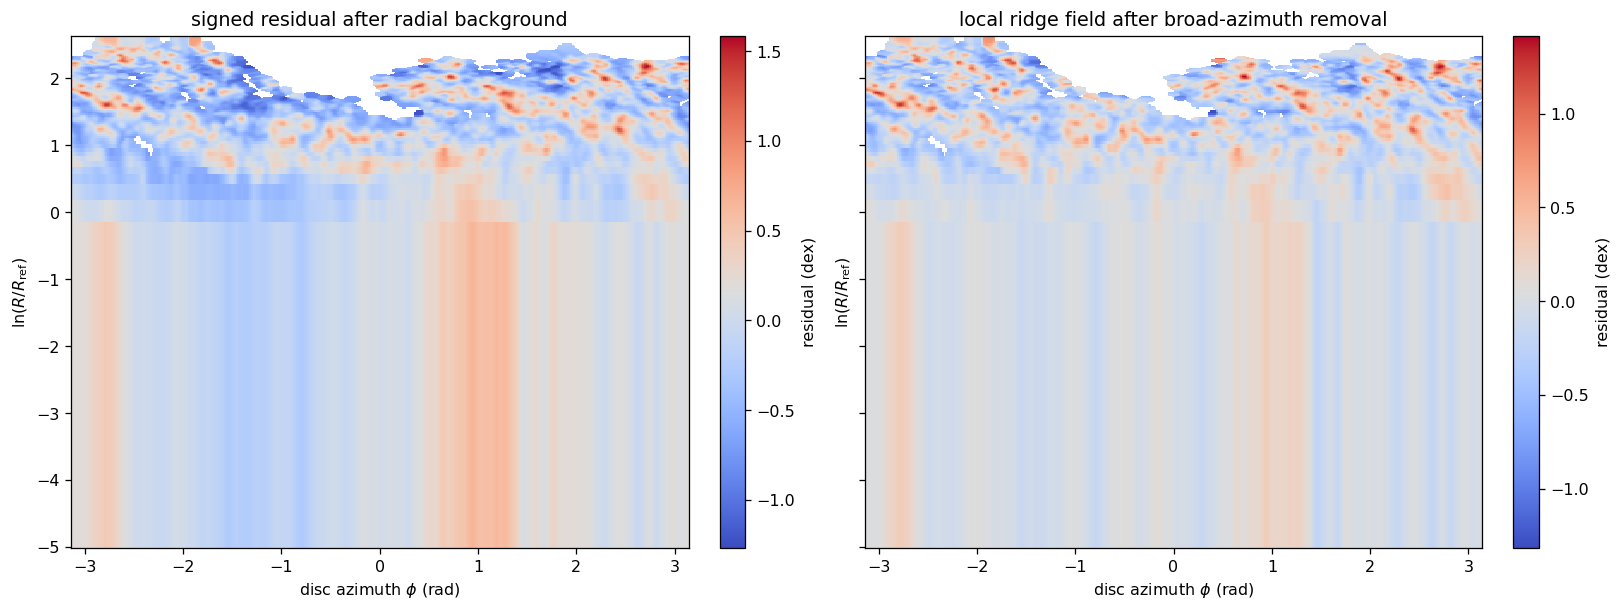

{'lambda0_0': 0.08853685734511911, 'h_R': 3.14303783409112, 'cost': 18691.642285605718, 'success': True, 'gradient_dex_per_kpc': -0.1381766637336193}


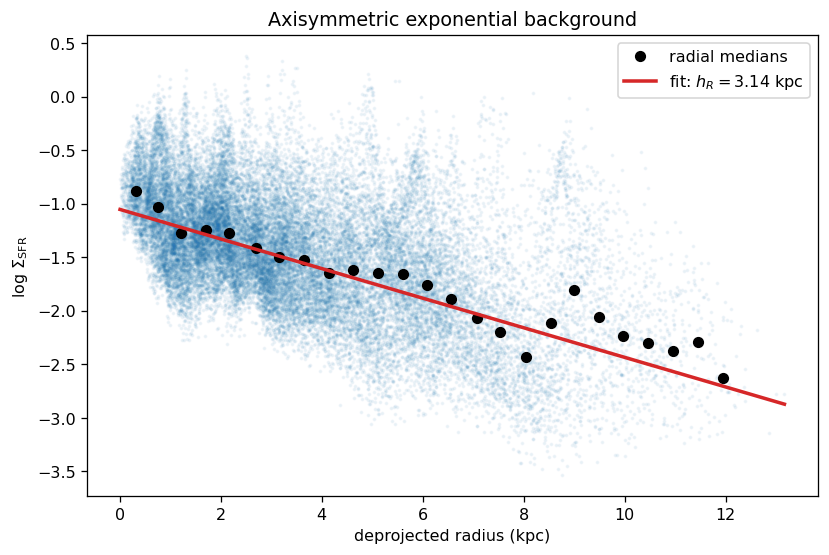

In [7]:
def fit_radial_exponential(radius, sfr_linear, area_weight):
    'Robustly fit lambda0*exp(-R/h_R) in log space.'
    radius = np.asarray(radius, dtype=float)
    sfr_linear = np.asarray(sfr_linear, dtype=float)
    weights = np.sqrt(np.asarray(area_weight, dtype=float))
    valid = (np.isfinite(radius) & np.isfinite(sfr_linear) &
             np.isfinite(weights) & (sfr_linear > 0) & (weights > 0))
    r = radius[valid]
    y = np.log(sfr_linear[valid])
    w = weights[valid] / np.nanmedian(weights[valid])
    initial = np.array([np.nanmedian(y), np.log(3.0)])

    def residual(theta):
        log_lambda0, log_h = theta
        return w * (y - (log_lambda0 - r / np.exp(log_h)))

    result = least_squares(residual, initial, loss="soft_l1", f_scale=0.3,
                           bounds=([-50.0, np.log(0.2)], [50.0, np.log(30.0)]))
    if not result.success:
        raise RuntimeError(result.message)
    return {"lambda0_0": float(np.exp(result.x[0])),
            "h_R": float(np.exp(result.x[1])),
            "cost": float(2.0 * result.cost), "success": True}


# Synthetic unit check of the radial fitter.
r_test = np.linspace(0.5, 8.0, 200)
radial_test = fit_radial_exponential(r_test, 0.025*np.exp(-r_test/3.4), np.ones_like(r_test))
assert abs(radial_test["h_R"] - 3.4) < 0.02

radial_fit = fit_radial_exponential(fit_table["radius_kpc"],
                                    fit_table["sfr_linear"], fit_table["area_pix"])
radial_fit["gradient_dex_per_kpc"] = float(
    -1.0 / (np.log(10.0) * radial_fit["h_R"]))
print(f"Axisymmetric SFR background h_R={radial_fit['h_R']:.3f} kpc; "
      f"gradient={radial_fit['gradient_dex_per_kpc']:.4f} dex/kpc")


def build_log_polar_contrast(
        pixel_table, radial_parameters,
        n_u=LOGPOLAR_N_U, n_phi=LOGPOLAR_N_PHI,
        smooth_sigma=LOGPOLAR_SMOOTH_SIGMA,
        broad_sigma_phi=LOGPOLAR_AZIMUTH_BROAD_SIGMA_BINS):
    radius = pixel_table["radius_kpc"].to_numpy(float)
    azimuth = pixel_table["azimuth_rad"].to_numpy(float)
    observed_log = pixel_table["log_sfr"].to_numpy(float)
    background_log = np.log10(radial_parameters["lambda0_0"]) \
        - radius / (np.log(10.0) * radial_parameters["h_R"])
    signed_residual = observed_log - background_log
    u = np.log(radius / R_REF_KPC)

    # Equal-count radial rows retain the central HII pixels and prevent the
    # much larger outer annuli from setting a global coverage threshold.
    u_edges = np.quantile(u, np.linspace(0.0, 1.0, n_u + 1))
    if np.any(np.diff(u_edges) <= 0):
        raise RuntimeError("Quantile log-radius edges are not strictly increasing")
    u_edges[0] = np.nextafter(u_edges[0], -np.inf)
    u_edges[-1] = np.nextafter(u_edges[-1], np.inf)
    phi_edges = np.linspace(-np.pi, np.pi, n_phi + 1)
    weighted_sum, _, _ = np.histogram2d(u, azimuth, bins=(u_edges, phi_edges),
                                        weights=signed_residual)
    coverage, _, _ = np.histogram2d(u, azimuth, bins=(u_edges, phi_edges))
    numerator = gaussian_filter(weighted_sum, smooth_sigma,
                                mode=("nearest", "wrap"))
    denominator = gaussian_filter(coverage, smooth_sigma,
                                  mode=("nearest", "wrap"))
    valid = denominator > 0.05
    radial_residual = np.full_like(numerator, np.nan, dtype=float)
    radial_residual[valid] = numerator[valid] / denominator[valid]

    # Remove diffuse/lopsided azimuthal structure without treating masks as
    # zero. Negative flanks remain informative and are deliberately not clipped.
    broad_numerator = gaussian_filter1d(
        np.where(valid, radial_residual * denominator, 0.0),
        broad_sigma_phi, axis=1, mode="wrap")
    broad_denominator = gaussian_filter1d(
        np.where(valid, denominator, 0.0),
        broad_sigma_phi, axis=1, mode="wrap")
    broad_azimuthal = np.divide(
        broad_numerator, broad_denominator,
        out=np.zeros_like(broad_numerator), where=broad_denominator > 0)
    local_ridge = np.full_like(radial_residual, np.nan)
    local_ridge[valid] = radial_residual[valid] - broad_azimuthal[valid]

    row_index = np.clip(np.searchsorted(u_edges, u, side="right") - 1,
                        0, n_u - 1)
    row_count = np.bincount(row_index, minlength=n_u)
    u_centres = np.divide(
        np.bincount(row_index, weights=u, minlength=n_u), row_count,
        out=np.full(n_u, np.nan), where=row_count > 0)
    phi_centres = 0.5 * (phi_edges[:-1] + phi_edges[1:])
    return {
        "radial_residual": radial_residual,
        "local_ridge": local_ridge,
        "coverage": denominator,
        "valid": valid,
        "u": u_centres,
        "phi": phi_centres,
        "u_edges": u_edges,
        "phi_edges": phi_edges,
    }


logpolar = build_log_polar_contrast(hii_pixels, radial_fit)
assert np.isfinite(logpolar["local_ridge"][logpolar["valid"]]).all()
assert len(hii_pixels) == int(valid_hii_pixels.sum())

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.2), constrained_layout=True,
                         sharex=True, sharey=True)
for ax, field, title in zip(
        axes, ["radial_residual", "local_ridge"],
        ["signed residual after radial background",
         "local ridge field after broad-azimuth removal"]):
    image = ax.pcolormesh(
        logpolar["phi_edges"], logpolar["u_edges"], logpolar[field],
        shading="auto", cmap="coolwarm")
    ax.set(xlabel=r"disc azimuth $\phi$ (rad)",
           ylabel=r"$\ln(R/R_{\rm ref})$", title=title)
    fig.colorbar(image, ax=ax, label="residual (dex)")
plt.show()

radial_model = radial_fit["lambda0_0"] * np.exp(-fit_table["radius_kpc"].to_numpy()/radial_fit["h_R"])
fit_table["radial_model"] = radial_model
fit_table["q"] = fit_table["sfr_linear"].to_numpy()/radial_model - 1.0
print(radial_fit)

radial_edges = np.linspace(R_IN_KPC, R_OUT_KPC, 28)
radial_index = np.digitize(fit_table["radius_kpc"], radial_edges) - 1
summary_rows = []
for idx in range(len(radial_edges)-1):
    use = radial_index == idx
    if use.sum() >= 10:
        summary_rows.append((np.median(fit_table.loc[use, "radius_kpc"]),
                             np.median(fit_table.loc[use, "log_sfr"]), use.sum()))
radial_summary = pd.DataFrame(summary_rows, columns=["radius_kpc", "median_log_sfr", "n"])

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.scatter(fit_table["radius_kpc"], fit_table["log_sfr"], s=2, alpha=0.06, color="tab:blue")
ax.plot(radial_summary["radius_kpc"], radial_summary["median_log_sfr"], "o", color="black", label="radial medians")
r_line = np.linspace(R_IN_KPC, R_OUT_KPC, 400)
ax.plot(r_line, np.log10(radial_fit["lambda0_0"]*np.exp(-r_line/radial_fit["h_R"])),
        color="tab:red", lw=2.2, label=fr"fit: $h_R={radial_fit['h_R']:.2f}$ kpc")
ax.set(xlabel="deprojected radius (kpc)", ylabel=r"log $\Sigma_{\rm SFR}$",
       title="Axisymmetric exponential background")
ax.legend()
plt.show()


In [8]:
def wrap_angle(angle):
    return np.angle(np.exp(1j*np.asarray(angle)))


def spiral_phase(radius, azimuth, m_arms, pitch_angle, theta0=0.0):
    pitch = np.deg2rad(pitch_angle)
    return ((m_arms/np.tan(pitch))*np.log(np.asarray(radius)/R_REF_KPC)
            - m_arms*np.asarray(azimuth) + theta0)


def arm_profile(theta, harmonic_g, harmonic_alpha):
    theta = np.asarray(theta, dtype=float)
    value = np.zeros_like(theta)
    for n, g, alpha in zip(HARMONIC_N, harmonic_g, harmonic_alpha):
        value += g*np.cos(n*theta + alpha)
    return value


def phase_sector_row_histograms(
        logpolar_map, m_arms, pitch_angle, field="local_ridge",
        n_phase=RIDGE_N_PHASE, n_sectors=RIDGE_N_SECTORS):
    uu, pp = np.meshgrid(logpolar_map["u"], logpolar_map["phi"], indexing="ij")
    valid = logpolar_map["valid"] & np.isfinite(logpolar_map[field])
    n_u = len(logpolar_map["u"])
    u = uu[valid]
    phi = pp[valid]
    row = np.broadcast_to(np.arange(n_u)[:, None], valid.shape)[valid]
    ridge_value = logpolar_map[field][valid]
    coverage = logpolar_map["coverage"][valid]
    base_phase = np.mod((m_arms / np.tan(np.deg2rad(pitch_angle))) * u
                        - m_arms * phi, 2.0 * np.pi)
    phase_index = np.floor(base_phase / (2.0 * np.pi) * n_phase).astype(int) % n_phase
    sector_index = np.floor((phi + np.pi) / (2.0 * np.pi) * n_sectors).astype(int)
    sector_index = np.clip(sector_index, 0, n_sectors - 1)
    joint_index = (sector_index * n_u + row) * n_phase + phase_index
    size = n_sectors * n_u * n_phase
    weighted = np.bincount(joint_index, weights=coverage * ridge_value,
                           minlength=size).reshape(n_sectors, n_u, n_phase)
    support = np.bincount(joint_index, weights=coverage,
                          minlength=size).reshape(n_sectors, n_u, n_phase)
    return weighted, support


def variable_width_ridge_response(
        weighted_hist, support_hist, u_centres, m_arms, pitch_angle,
        core_width_kpc=RIDGE_CORE_WIDTH_KPC,
        broad_ratio=RIDGE_BROAD_RATIO,
        n_radial_bands=LOGPOLAR_N_RADIAL_BANDS):
    """Local centre-minus-flanks response at a constant physical width."""
    n_u, n_phase = weighted_hist.shape
    if n_u % n_radial_bands:
        raise ValueError("LOGPOLAR_N_U must be divisible by radial-band count")
    rows_per_band = n_u // n_radial_bands
    weighted_band = weighted_hist.reshape(
        n_radial_bands, rows_per_band, n_phase).sum(axis=1)
    support_band = support_hist.reshape(
        n_radial_bands, rows_per_band, n_phase).sum(axis=1)
    u_band = np.asarray(u_centres).reshape(
        n_radial_bands, rows_per_band).mean(axis=1)
    radius_band = R_REF_KPC * np.exp(u_band)
    sine_pitch = abs(np.sin(np.deg2rad(pitch_angle)))
    sigma_phase = m_arms * core_width_kpc / (radius_band * sine_pitch)
    sigma_bins = np.clip(
        sigma_phase / (2.0 * np.pi) * n_phase, 0.65, n_phase / 10.0)

    narrow_mean = np.full_like(weighted_band, np.nan, dtype=float)
    broad_mean = np.full_like(weighted_band, np.nan, dtype=float)
    narrow_support = np.zeros_like(support_band, dtype=float)
    for radial_index, sigma_bin in enumerate(sigma_bins):
        narrow_weighted = gaussian_filter1d(
            weighted_band[radial_index], sigma_bin, mode="wrap")
        narrow_denominator = gaussian_filter1d(
            support_band[radial_index], sigma_bin, mode="wrap")
        broad_weighted = gaussian_filter1d(
            weighted_band[radial_index], broad_ratio * sigma_bin, mode="wrap")
        broad_denominator = gaussian_filter1d(
            support_band[radial_index], broad_ratio * sigma_bin, mode="wrap")
        narrow_mean[radial_index] = np.divide(
            narrow_weighted, narrow_denominator,
            out=np.full(n_phase, np.nan), where=narrow_denominator > 0.05)
        broad_mean[radial_index] = np.divide(
            broad_weighted, broad_denominator,
            out=np.full(n_phase, np.nan), where=broad_denominator > 0.05)
        narrow_support[radial_index] = narrow_denominator
    return narrow_mean - broad_mean, narrow_mean, broad_mean, narrow_support


def aggregate_radial_response(response, support, min_radial_fraction=0.35):
    """Give each approximately equal-count radial band one vote."""
    good = np.isfinite(response) & (support > 0.05)
    count = good.sum(axis=0)
    total = np.where(good, response, 0.0).sum(axis=0)
    mean_response = np.divide(
        total, count, out=np.full(response.shape[1], np.nan), where=count > 0)
    positive_count = (good & (response > 0)).sum(axis=0)
    positive_fraction = np.divide(
        positive_count, count,
        out=np.full(response.shape[1], np.nan), where=count > 0)
    median_response = np.array([
        np.median(response[good[:, index], index]) if count[index] else np.nan
        for index in range(response.shape[1])
    ])
    radial_fraction = count / response.shape[0]
    combined = mean_response * positive_fraction + 0.5 * median_response
    combined[radial_fraction < min_radial_fraction] = np.nan
    return {
        "score": combined,
        "mean": mean_response,
        "median": median_response,
        "positive_fraction": positive_fraction,
        "radial_fraction": radial_fraction,
    }


def held_out_ridge_search(logpolar_map, m_candidates=M_CANDIDATES,
                          pitch_grid=RIDGE_PITCH_GRID_DEG,
                          core_width_kpc=RIDGE_CORE_WIDTH_KPC,
                          allow_no_acceptance=False):
    records = []
    histogram_cache = {}
    branch_normalization = "mean_not_sum"
    phase_values = np.linspace(0.0, 2.0 * np.pi, RIDGE_N_PHASE, endpoint=False)
    for m_arms in m_candidates:
        for pitch_angle in pitch_grid:
            weighted, support = phase_sector_row_histograms(
                logpolar_map, int(m_arms), float(pitch_angle))
            histogram_cache[(int(m_arms), float(pitch_angle))] = (weighted, support)
            total_weighted = weighted.sum(axis=0)
            total_support = support.sum(axis=0)
            response, narrow, broad, response_support = variable_width_ridge_response(
                total_weighted, total_support, logpolar_map["u"],
                int(m_arms), float(pitch_angle), core_width_kpc)
            full = aggregate_radial_response(response, response_support)
            if not np.isfinite(full["score"]).any():
                continue
            full_index = int(np.nanargmax(full["score"]))
            records.append({
                "m_arms": int(m_arms),
                "pitch_angle": float(pitch_angle),
                "winding_sign": int(np.sign(pitch_angle)),
                "Theta0": float((-phase_values[full_index]) % (2.0*np.pi)),
                "core_width_kpc": float(core_width_kpc),
                "full_ridge_score": float(full["score"][full_index]),
                "narrow_mean": float(np.nanmean(narrow[:, full_index])),
                "broad_flank_mean": float(np.nanmean(broad[:, full_index])),
                "positive_radial_fraction": float(full["positive_fraction"][full_index]),
                "radial_coverage": float(full["radial_fraction"][full_index]),
                "branch_normalization": branch_normalization,
                "held_out_score": np.nan,
                "held_out_score_std": np.nan,
                "phase_stability": np.nan,
                "valid_held_out": 0,
                "validated_score": np.nan,
            })
    table = pd.DataFrame(records)
    if table.empty:
        raise RuntimeError("No ridge candidate had finite full-map support")
    shortlist = (table.sort_values("full_ridge_score", ascending=False)
                 .groupby(["m_arms", "winding_sign"], group_keys=False)
                 .head(RIDGE_SHORTLIST_PER_FAMILY).index)
    for record_index in shortlist:
        m_arms = int(table.at[record_index, "m_arms"])
        pitch_angle = float(table.at[record_index, "pitch_angle"])
        weighted, support = histogram_cache[(m_arms, pitch_angle)]
        total_weighted = weighted.sum(axis=0)
        total_support = support.sum(axis=0)
        held_out_scores = []
        held_out_phases = []
        for sector in range(RIDGE_N_SECTORS):
            train_response, _, _, train_support = variable_width_ridge_response(
                total_weighted - weighted[sector], total_support - support[sector],
                logpolar_map["u"], m_arms, pitch_angle, core_width_kpc)
            train = aggregate_radial_response(train_response, train_support)
            if not np.isfinite(train["score"]).any():
                continue
            train_index = int(np.nanargmax(train["score"]))
            test_response, _, _, test_support = variable_width_ridge_response(
                weighted[sector], support[sector], logpolar_map["u"],
                m_arms, pitch_angle, core_width_kpc)
            test = aggregate_radial_response(
                test_response, test_support, min_radial_fraction=0.08)
            if np.isfinite(test["score"][train_index]):
                held_out_scores.append(float(test["score"][train_index]))
                held_out_phases.append(float((-phase_values[train_index]) % (2*np.pi)))
        valid_held_out = len(held_out_scores)
        if valid_held_out:
            phase_stability = float(np.abs(np.mean(
                np.exp(1j * np.asarray(held_out_phases)))))
            held_out_score = float(np.median(held_out_scores))
            table.at[record_index, "held_out_score"] = held_out_score
            table.at[record_index, "held_out_score_std"] = float(np.std(held_out_scores))
            table.at[record_index, "phase_stability"] = phase_stability
            table.at[record_index, "valid_held_out"] = valid_held_out
            table.at[record_index, "validated_score"] = (
                max(held_out_score, 0.0) * (valid_held_out/RIDGE_N_SECTORS)
                * phase_stability)
    accepted = table.loc[
        (table["valid_held_out"] >= RIDGE_MIN_HELD_OUT_SECTORS)
        & (table["validated_score"] > 0)].copy()
    if accepted.empty and not allow_no_acceptance:
        raise RuntimeError("No ridge candidate passed sector-support acceptance")
    ranked = table.sort_values(["validated_score", "full_ridge_score"],
                               ascending=False, na_position="last").reset_index(drop=True)
    if accepted.empty:
        return None, ranked
    accepted = accepted.sort_values(["validated_score", "full_ridge_score"],
                                    ascending=False)
    return accepted.iloc[0].to_dict(), ranked

In [9]:
# %% Task 4: Fit KTZ profile at fixed geometry and enumerate maxima
def fit_ktz_profile_fixed_geometry(table, geometry, radial_guess):
    radius = table["radius_kpc"].to_numpy(float)
    azimuth = table["azimuth_rad"].to_numpy(float)
    observed_log = np.log(table["sfr_linear"].to_numpy(float))
    sqrt_weight = np.sqrt(table["area_pix"].to_numpy(float))
    sqrt_weight /= np.nanmedian(sqrt_weight)
    theta = spiral_phase(radius, azimuth, int(geometry["m_arms"]),
                         float(geometry["pitch_angle"]), float(geometry["Theta0"]))
    initial = np.array([
        np.log(radial_guess["lambda0_0"]), np.log(radial_guess["h_R"]),
        np.log(0.2), 0.3, 0.15, 0.0, 0.0,
    ])
    lower = np.array([-50.0, np.log(0.2), np.log(1e-4),
                      0.0, 0.0, -np.pi, -np.pi])
    upper = np.array([50.0, np.log(30.0), np.log(2.0),
                      1.5, 1.5, np.pi, np.pi])
    dense_theta = np.linspace(0.0, 2.0*np.pi, 8192, endpoint=False)

    def unpack(values):
        return {
            "lambda0_0": float(np.exp(values[0])),
            "h_R": float(np.exp(values[1])),
            "eta": float(np.exp(values[2])),
            "harmonic_n": HARMONIC_N.copy(),
            "harmonic_g": np.array([1.0, values[3], values[4]]),
            "harmonic_alpha": np.array([0.0, values[5], values[6]]),
        }

    def residual(values):
        parameters = unpack(values)
        profile = arm_profile(theta, parameters["harmonic_g"],
                              parameters["harmonic_alpha"])
        factor = 1.0 + parameters["eta"] * profile
        dense_factor = 1.0 + parameters["eta"] * arm_profile(
            dense_theta, parameters["harmonic_g"], parameters["harmonic_alpha"])
        model_log = (np.log(parameters["lambda0_0"])
                     - radius / parameters["h_R"]
                     + np.log(np.clip(factor, 1e-10, None)))
        positivity_penalty = min(0.0, float(np.min(dense_factor)) - 1e-3) * 1e5
        return np.concatenate([sqrt_weight * (observed_log - model_log),
                               [positivity_penalty]])

    result = least_squares(residual, initial, bounds=(lower, upper),
                           loss="soft_l1", f_scale=0.25, max_nfev=3000)
    parameters = unpack(result.x)
    final_residual = residual(result.x)
    minimum_factor = float(np.min(1.0 + parameters["eta"] * arm_profile(
        dense_theta, parameters["harmonic_g"], parameters["harmonic_alpha"])))
    parameters.update({
        "m_arms": int(geometry["m_arms"]),
        "pitch_angle": float(geometry["pitch_angle"]),
        "Theta0": float(geometry["Theta0"]),
        "geometry_source": "null_calibrated_local_ridge",
        "weighted_log_sse": float(np.sum(final_residual[:-1]**2)),
        "positivity_penalty_residual": float(final_residual[-1]),
        "robust_cost": float(2.0 * result.cost),
        "minimum_rate_factor": minimum_factor,
        "success": bool(result.success and minimum_factor > 0.0),
        "message": result.message,
    })
    if not parameters["success"]:
        raise RuntimeError(f"Fixed-geometry KTZ fit failed: {parameters}")
    return parameters

def enumerate_profile_maxima(model, n_grid=65536):
    theta = np.linspace(0.0, 2.0*np.pi, n_grid, endpoint=False)
    profile = arm_profile(theta, model["harmonic_g"], model["harmonic_alpha"])
    maxima = (profile > np.roll(profile, 1)) & (profile >= np.roll(profile, -1))
    indices = np.flatnonzero(maxima)
    if len(indices) == 0:
        raise RuntimeError("No harmonic-profile maximum found")
    grid_step = 2.0 * np.pi / n_grid

    def profile_scalar(value):
        wrapped_value = float(value % (2.0*np.pi))
        return float(arm_profile(
            np.array([wrapped_value]),
            model["harmonic_g"], model["harmonic_alpha"])[0])

    rows = []
    for index in indices:
        centre = float(theta[index])
        refined = minimize_scalar(
            lambda offset: -profile_scalar(centre + offset),
            bounds=(-grid_step, grid_step), method="bounded",
            options={"xatol": 1e-12})
        theta_peak = float((centre + refined.x) % (2.0*np.pi))
        h_peak = profile_scalar(theta_peak)
        factor = float(1.0 + model["eta"] * h_peak)
        rows.append({
            "theta_peak": theta_peak,
            "h_peak": h_peak,
            "rate_factor": factor,
            "enhanced_above_background": bool(factor > 1.0),
        })
    return pd.DataFrame(rows).sort_values("rate_factor", ascending=False).reset_index(drop=True)


In [10]:
# %% Run search and fit KTZ profile on observed data
# We run held_out_ridge_search to find the geometry parameters (allow_no_acceptance=True to skip null bootstrapping for speed)
ridge_geometry, ranked_table = held_out_ridge_search(logpolar, allow_no_acceptance=True)
print("RIDGE_REAL_FIT_COMPLETE")
print(ridge_geometry)

# Fit the profile
real_fit = fit_ktz_profile_fixed_geometry(fit_table, ridge_geometry, radial_fit)
real_fit["gradient_dex_per_kpc"] = float(-1.0 / (np.log(10.0) * real_fit["h_R"]))
theta_fit = spiral_phase(
    fit_table["radius_kpc"].to_numpy(float),
    fit_table["azimuth_rad"].to_numpy(float),
    real_fit["m_arms"], real_fit["pitch_angle"], real_fit["Theta0"],
)
rate_factor = 1.0 + real_fit["eta"] * arm_profile(
    theta_fit, real_fit["harmonic_g"], real_fit["harmonic_alpha"])
model_sfr = (real_fit["lambda0_0"]
             * np.exp(-fit_table["radius_kpc"].to_numpy(float) / real_fit["h_R"])
             * rate_factor)
fit_table = fit_table.copy()
fit_table["theta_fit"] = np.mod(theta_fit, 2.0*np.pi)
fit_table["rate_factor"] = rate_factor
fit_table["model_sfr"] = model_sfr
fit_table["residual_dex"] = np.log10(
    fit_table["sfr_linear"].to_numpy(float)
    / np.clip(model_sfr, 1e-30, None))
profile_maxima = enumerate_profile_maxima(real_fit)
print("KTZ_PROFILE_FIT_COMPLETE")
print("HARMONIC_MAXIMA_COMPLETE")
print("POSITIVITY_CHECK_PASS")
print(real_fit)


RIDGE_REAL_FIT_COMPLETE
{'m_arms': 3, 'pitch_angle': -33.0, 'winding_sign': -1, 'Theta0': 5.707226654021458, 'core_width_kpc': 0.25, 'full_ridge_score': 0.11508769783799702, 'narrow_mean': 0.14820968167579138, 'broad_flank_mean': 0.05823331084023769, 'positive_radial_fraction': 0.6666666666666666, 'radial_coverage': 1.0, 'branch_normalization': 'mean_not_sum', 'held_out_score': 0.045891783419080984, 'held_out_score_std': 0.06630529788405448, 'phase_stability': 0.9952233171861241, 'valid_held_out': 12, 'validated_score': 0.04567257292592494}
KTZ_PROFILE_FIT_COMPLETE
HARMONIC_MAXIMA_COMPLETE
POSITIVITY_CHECK_PASS
{'lambda0_0': 0.08985166939479401, 'h_R': 3.120528343552912, 'eta': 0.19552325689340525, 'harmonic_n': array([1, 2, 3]), 'harmonic_g': array([1.        , 1.1777614 , 0.71466529]), 'harmonic_alpha': array([0.        , 0.59524903, 0.2008339 ]), 'm_arms': 3, 'pitch_angle': -33.0, 'Theta0': 5.707226654021458, 'geometry_source': 'null_calibrated_local_ridge', 'weighted_log_sse': 1143

In [11]:
# %% Plot helpers for sky projection
def skeleton_xy_for_phase(geometry, radius_grid, theta_target=0.0):
    curves = []
    m_arms = int(geometry["m_arms"])
    pitch = np.deg2rad(float(geometry["pitch_angle"]))
    theta0 = float(geometry["Theta0"])
    for branch in range(m_arms):
        phi = ((m_arms / np.tan(pitch)) * np.log(radius_grid / R_REF_KPC)
               + theta0 - theta_target - 2.0*np.pi*branch) / m_arms
        curves.append((radius_grid * np.cos(phi), radius_grid * np.sin(phi)))
    return curves

def project_disc_to_pixel(x_disc, y_disc):
    pa_rad = np.deg2rad(POSITION_ANGLE_DEG)
    inc_rad = np.deg2rad(INCLINATION_DEG)
    major = np.asarray(x_disc)
    minor_projected = np.asarray(y_disc) * np.cos(inc_rad)
    east_kpc = major * np.sin(pa_rad) - minor_projected * np.cos(pa_rad)
    north_kpc = major * np.cos(pa_rad) + minor_projected * np.sin(pa_rad)
    sky = CENTER.spherical_offsets_by(
        east_kpc / ARCSEC_TO_KPC * u.arcsec,
        north_kpc / ARCSEC_TO_KPC * u.arcsec,
    )
    return celestial_wcs.world_to_pixel(sky)

radius_grid = np.geomspace(RIDGE_R_IN_KPC, RIDGE_R_OUT_KPC, 1000)
data_ridge_curves = skeleton_xy_for_phase(ridge_geometry, radius_grid, theta_target=0.0)
enhanced_model_curves = []
for row in profile_maxima.itertuples(index=False):
    if row.enhanced_above_background:
        enhanced_model_curves.append({
            "theta_peak": row.theta_peak,
            "rate_factor": row.rate_factor,
            "curves": skeleton_xy_for_phase(real_fit, radius_grid, row.theta_peak),
        })


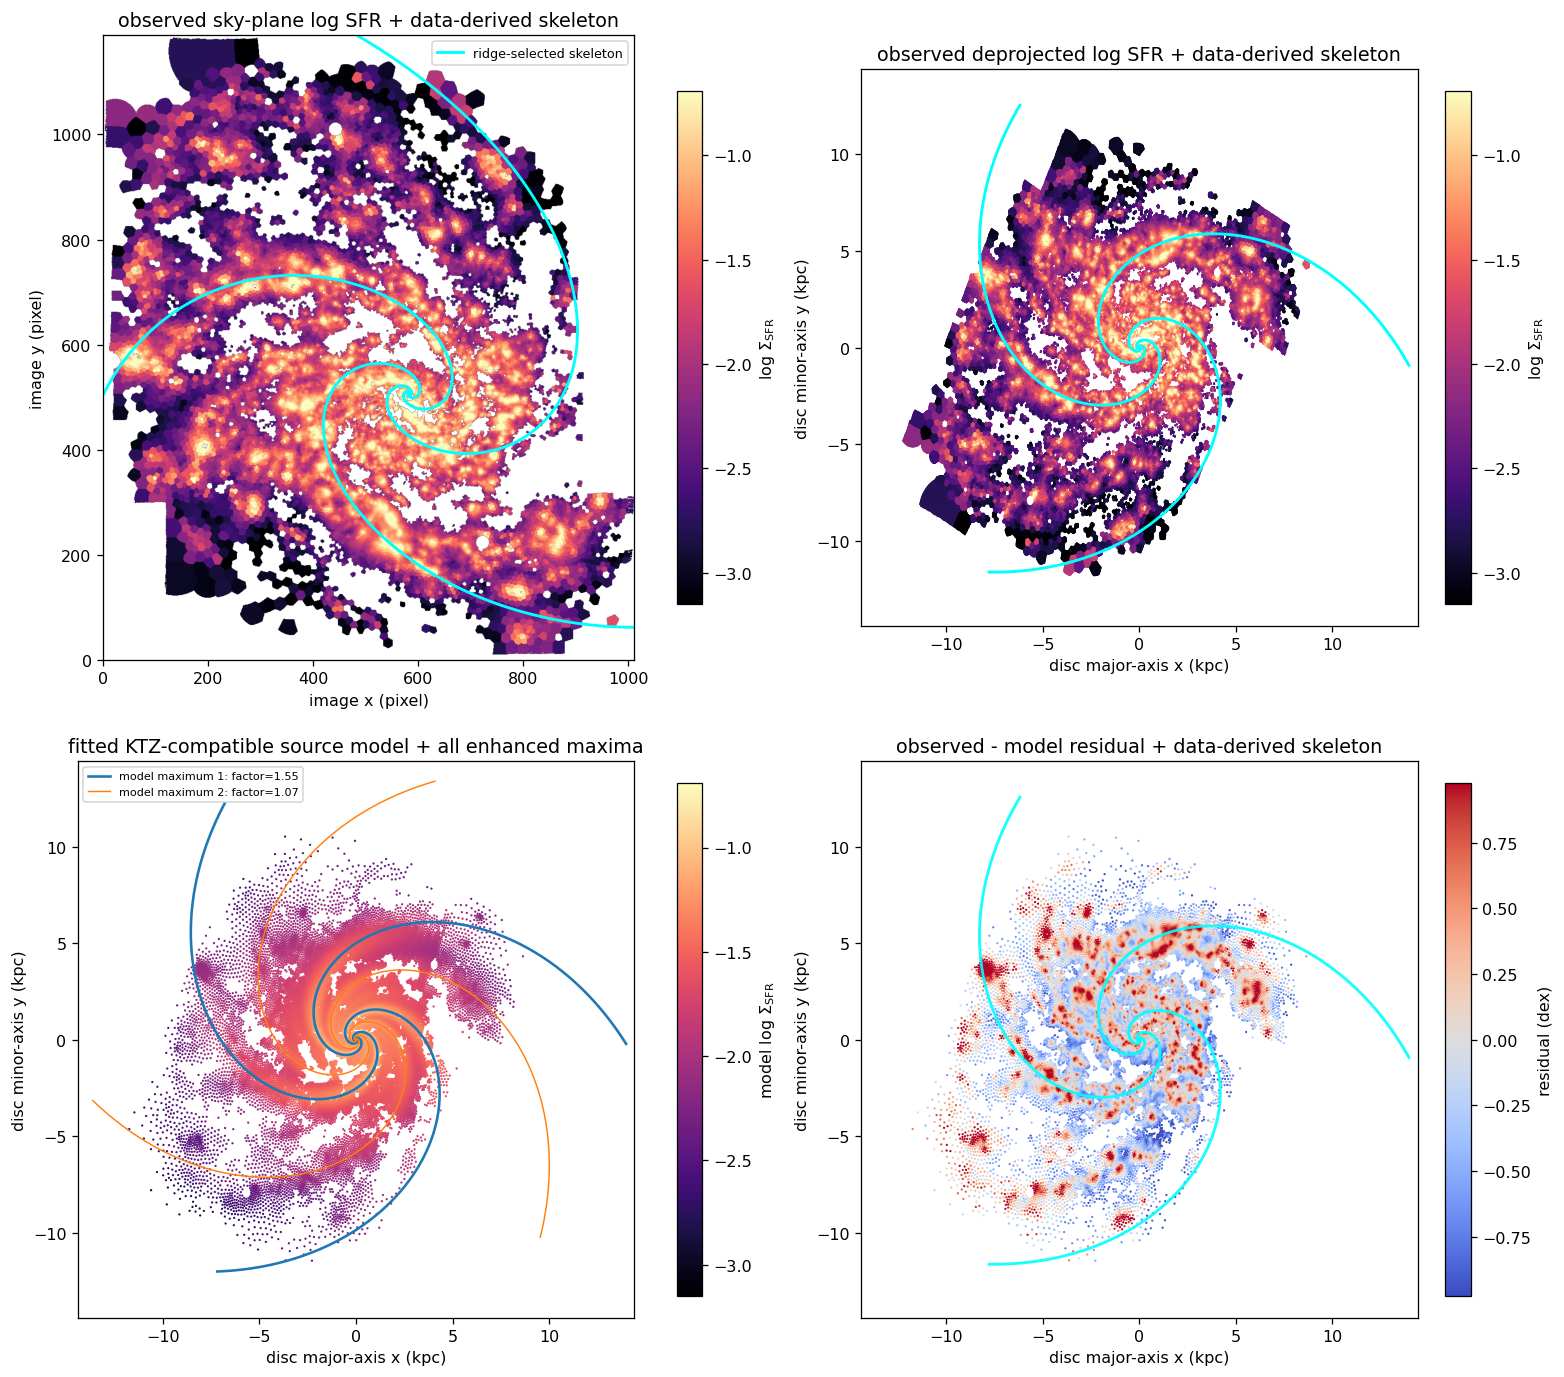

DEPROJECTED_SFR_SKELETON_PASS


In [12]:
# %% 2x2 Diagnostic Plot Layout
fig, axes = plt.subplots(2, 2, figsize=(13.5, 12.0), constrained_layout=True)
ax_sky, ax_face, ax_model, ax_residual = axes.ravel()
disc_limit = 1.03 * RIDGE_R_OUT_KPC

sky_image = ax_sky.imshow(log_sfr_map, origin="lower", cmap="magma", vmin=vmin, vmax=vmax)
for index, (x_curve, y_curve) in enumerate(data_ridge_curves):
    xp, yp = project_disc_to_pixel(x_curve, y_curve)
    ax_sky.plot(xp, yp, color="cyan", lw=1.8,
                label="ridge-selected skeleton" if index == 0 else "_nolegend_")
ax_sky.set(xlim=(0, log_sfr_map.shape[1]-1),
           ylim=(0, log_sfr_map.shape[0]-1),
           xlabel="image x (pixel)", ylabel="image y (pixel)",
           title="observed sky-plane log SFR + data-derived skeleton")
ax_sky.set_aspect("equal")
ax_sky.legend(fontsize=8)
fig.colorbar(sky_image, ax=ax_sky, shrink=0.82, label=r"log $\Sigma_{\rm SFR}$")

face_scatter = ax_face.scatter(hii_pixels["x_disc_kpc"], hii_pixels["y_disc_kpc"],
                               c=hii_pixels["log_sfr"], s=0.35, cmap="magma",
                               vmin=vmin, vmax=vmax, linewidth=0, rasterized=True)
for x_curve, y_curve in data_ridge_curves:
    ax_face.plot(x_curve, y_curve, color="cyan", lw=1.8)
ax_face.set(xlabel="disc major-axis x (kpc)", ylabel="disc minor-axis y (kpc)",
            title="observed deprojected log SFR + data-derived skeleton",
            xlim=(-disc_limit, disc_limit), ylim=(-disc_limit, disc_limit))
ax_face.set_aspect("equal")
fig.colorbar(face_scatter, ax=ax_face, shrink=0.82, label=r"log $\Sigma_{\rm SFR}$")

model_scatter = ax_model.scatter(fit_table["x_disc_kpc"], fit_table["y_disc_kpc"],
                                 c=np.log10(fit_table["model_sfr"]), s=2.0,
                                 cmap="magma", vmin=vmin, vmax=vmax, linewidth=0)
for peak_index, peak in enumerate(enhanced_model_curves):
    width = 0.8 + 1.5 * (peak["rate_factor"] - 1.0)
    colour = f"C{peak_index % 10}"
    for branch_index, (x_curve, y_curve) in enumerate(peak["curves"]):
        label = (fr"model maximum {peak_index+1}: factor={peak['rate_factor']:.2f}"
                 if branch_index == 0 else "_nolegend_")
        ax_model.plot(x_curve, y_curve, color=colour, lw=width, label=label)
ax_model.set(xlabel="disc major-axis x (kpc)", ylabel="disc minor-axis y (kpc)",
             title="fitted KTZ-compatible source model + all enhanced maxima",
             xlim=(-disc_limit, disc_limit), ylim=(-disc_limit, disc_limit))
ax_model.set_aspect("equal")
ax_model.legend(fontsize=7)
fig.colorbar(model_scatter, ax=ax_model, shrink=0.82, label=r"model log $\Sigma_{\rm SFR}$")

limit = np.nanpercentile(np.abs(fit_table["residual_dex"]), 95)
residual_scatter = ax_residual.scatter(
    fit_table["x_disc_kpc"], fit_table["y_disc_kpc"],
    c=fit_table["residual_dex"], s=2.0, cmap="coolwarm",
    vmin=-limit, vmax=limit, linewidth=0)
for x_curve, y_curve in data_ridge_curves:
    ax_residual.plot(x_curve, y_curve, color="cyan", lw=1.8, alpha=0.9)
ax_residual.set(xlabel="disc major-axis x (kpc)", ylabel="disc minor-axis y (kpc)",
                title="observed - model residual + data-derived skeleton",
                xlim=(-disc_limit, disc_limit), ylim=(-disc_limit, disc_limit))
ax_residual.set_aspect("equal")
fig.colorbar(residual_scatter, ax=ax_residual, shrink=0.82, label="residual (dex)")
plt.show()
print("DEPROJECTED_SFR_SKELETON_PASS")


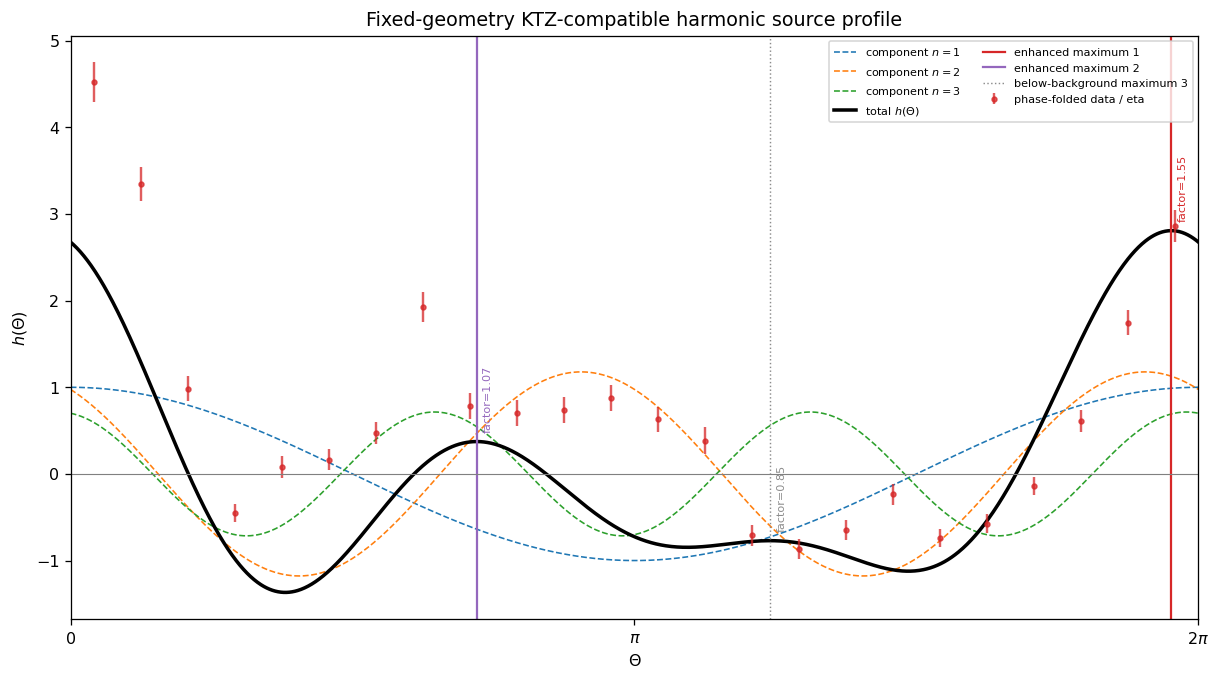

Minimum fitted rate factor: 0.7326
POSITIVITY_CHECK_PASS


In [13]:
# %% Fitted KTZ-compatible harmonic source profile plot
theta_grid = np.linspace(0.0, 2.0*np.pi, 1600)
profile_total = arm_profile(theta_grid, real_fit["harmonic_g"], real_fit["harmonic_alpha"])
rate_factor_grid = 1.0 + real_fit["eta"] * profile_total

final_background = (real_fit["lambda0_0"]
    * np.exp(-fit_table["radius_kpc"].to_numpy(float) / real_fit["h_R"]))
fit_table["q_final_background"] = (
    fit_table["sfr_linear"].to_numpy(float) / final_background - 1.0)
phase_edges = np.linspace(0.0, 2.0*np.pi, 25)
phase_index = np.digitize(fit_table["theta_fit"], phase_edges) - 1
phase_rows = []
for phase_bin in range(len(phase_edges) - 1):
    use = phase_index == phase_bin
    if use.sum() >= 10:
        values = fit_table.loc[use, "q_final_background"].to_numpy(float)
        median = float(np.median(values))
        robust_sigma = float(1.4826 * np.median(np.abs(values - median)))
        phase_rows.append({
            "theta": 0.5 * (phase_edges[phase_bin] + phase_edges[phase_bin + 1]),
            "q_over_eta": median / real_fit["eta"],
            "q_over_eta_sem": robust_sigma / np.sqrt(use.sum()) / real_fit["eta"],
        })
phase_summary = pd.DataFrame(phase_rows)

fig, ax = plt.subplots(figsize=(10.5, 5.8), constrained_layout=True)
for n, g, alpha in zip(
        HARMONIC_N, real_fit["harmonic_g"], real_fit["harmonic_alpha"]):
    ax.plot(theta_grid, g * np.cos(n*theta_grid + alpha), "--", lw=1,
            label=fr"component $n={n}$")
ax.plot(theta_grid, profile_total, "k-", lw=2.2, label=r"total $h(\Theta)$")
ax.errorbar(phase_summary["theta"], phase_summary["q_over_eta"],
            yerr=phase_summary["q_over_eta_sem"], fmt="o", ms=3,
            color="tab:red", alpha=0.75, label="phase-folded data / eta")
for peak_index, row in enumerate(profile_maxima.itertuples(index=False)):
    if row.enhanced_above_background:
        colour = f"C{(peak_index + 3) % 10}"
        linestyle = "-"
        width = 1.4
        label = f"enhanced maximum {peak_index + 1}"
    else:
        colour = "0.55"
        linestyle = ":"
        width = 0.9
        label = f"below-background maximum {peak_index + 1}"
    ax.axvline(row.theta_peak, color=colour, ls=linestyle, lw=width,
               label=label)
    ax.annotate(f"factor={row.rate_factor:.2f}",
                (row.theta_peak, row.h_peak), xytext=(4, 7),
                textcoords="offset points", rotation=90, fontsize=7,
                color=colour)
ax.axhline(0.0, color="0.5", lw=0.7)
ax.set(xlim=(0.0, 2.0*np.pi), xlabel=r"$\Theta$", ylabel=r"$h(\Theta)$",
       title="Fixed-geometry KTZ-compatible harmonic source profile")
ax.set_xticks([0.0, np.pi, 2.0*np.pi], [r"$0$", r"$\pi$", r"$2\pi$"])
ax.legend(fontsize=7, ncol=2)
plt.show()
print(f"Minimum fitted rate factor: {np.min(rate_factor_grid):.4f}")
print("POSITIVITY_CHECK_PASS")


In [14]:
# %% Parameter table reporting
parameter_rows = [
    ("R_in", R_IN_KPC, "kpc", "all positive-radius valid HII bins; no hole"),
    ("R_out", R_OUT_KPC, "kpc", "all valid HII bins; no quantile cut"),
    ("ridge_R_in", RIDGE_R_IN_KPC, "kpc", "all positive-radius valid HII pixels"),
    ("ridge_R_out", RIDGE_R_OUT_KPC, "kpc", "all valid HII morphology pixels"),
    ("m_arms", real_fit["m_arms"], "integer base mode", "ridge-selected"),
    ("pitch_angle", real_fit["pitch_angle"], "signed deg", "ridge-selected"),
    ("Theta0", real_fit["Theta0"], "rad modulo 2 pi", "ridge-selected"),
    ("ridge_core_width", RIDGE_CORE_WIDTH_KPC, "kpc", "declared fiducial local-ridge scale"),
    ("lambda0_0", real_fit["lambda0_0"], "SFR surface-density normalization", "fixed-geometry KTZ fit; uncertainty not estimated"),
    ("h_R", real_fit["h_R"], "kpc", "axisymmetric SFR e-folding length; fixed-geometry KTZ fit"),
    ("radial_gradient", real_fit["gradient_dex_per_kpc"], "dex/kpc", "equals -1 / (ln(10) h_R)"),
    ("eta", real_fit["eta"], "dimensionless", "fixed-geometry KTZ fit; uncertainty not estimated"),
    ("harmonic_n", str(real_fit["harmonic_n"].tolist()), "integer orders", "fixed"),
    ("harmonic_g", np.array2string(real_fit["harmonic_g"], precision=4), "g1=1 normalization", "fixed-geometry KTZ fit"),
    ("harmonic_alpha", np.array2string(real_fit["harmonic_alpha"], precision=4), "rad; alpha1=0", "fixed-geometry KTZ fit"),
    ("kappa, x0, t_star, clustering", np.nan, "KTZ mixing parameters", "not fitted from SFR morphology"),
]
parameter_table = pd.DataFrame(
    parameter_rows, columns=["parameter", "estimate", "unit_or_convention", "status"])
display(parameter_table)
display(profile_maxima)
print("FINAL_PARAMETER_TABLE_COMPLETE")


,parameter,estimate,unit_or_convention,status
0,R_in,0.008545,kpc,all positive-radius valid HII bins; no hole
1,R_out,13.16348,kpc,all valid HII bins; no quantile cut
2,ridge_R_in,0.006642,kpc,all positive-radius valid HII pixels
3,ridge_R_out,13.989577,kpc,all valid HII morphology pixels
4,m_arms,3,integer base mode,ridge-selected
5,pitch_angle,-33.0,signed deg,ridge-selected
6,Theta0,5.707227,rad modulo 2 pi,ridge-selected
7,ridge_core_width,0.25,kpc,declared fiducial local-ridge scale
8,lambda0_0,0.089852,SFR surface-density normalization,fixed-geometry KTZ fit; uncertainty not estimated
9,h_R,3.120528,kpc,axisymmetric SFR e-folding length; fixed-geome...


,theta_peak,h_peak,rate_factor,enhanced_above_background
0,6.132566,2.808168,1.549062,True
1,2.262911,0.373533,1.073034,True
2,3.896220,-0.770583,0.849333,False


FINAL_PARAMETER_TABLE_COMPLETE
